# 12 — Exposição e inadimplência na mesma UF

Esta etapa é uma extensão informada pelos resultados anteriores. Consulte `docs/segunda_etapa_protocolo.md`, registrado no GitHub antes dos testes. Precedência preditiva e associações condicionais não identificam causalidade estrutural.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT/'src'))
from segunda_etapa import *
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize':(12,5),'font.size':11})
pd.set_option('display.max_columns', 20)
def tabela(d):
    display(d.round(5))
def resumo(d):
    tabela(d.groupby(['Família','Período','Categoria resultado']).size().reset_index(name='Modelos'))


## 1. Por que usar um painel?
Efeitos de UF absorvem diferenças permanentes; efeitos de mês-calendário absorvem choques comuns. A variação de inadimplência tem histórico1,2,3 e12; exposição usa lags1–3 fixos. Não são27 regressões independentes. DK considera dependência temporal e entre estados, com aproximação t/F de26 graus de liberdade; não garante exogeneidade. GMM não é aplicado automaticamente.

In [2]:
r=panel()
resumo(r)
tabela(r)

,Família,Período,Categoria resultado,Modelos
0,PAINEL,Pré-pandemia (até jan/2020),Diagnósticos inadequados ou inconclusivos,4
1,PAINEL,Total (2013–2024),Diagnósticos inadequados ou inconclusivos,4


,Período,Unidade,Exposição,Família,Modelo,Transformação,Controles,p próprio,q exposição,n efetivo,...,LOO mínimo,LOO máximo,Diagnóstico favorável,Motivo,Unidade efeito,Família n,p BH,p BY,p Holm,Categoria resultado
0,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,3537,...,-0.00394,0.00032,False,"SPJ é sensibilidade de ponto, IC original não ...","pp ΔI por unidade Δlog exposição; soma lags, n...",8,0.90666,1.0,1.00000,Diagnósticos inadequados ou inconclusivos
1,Total (2013–2024),UF × mês,Clima | Municípios,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,3537,...,-0.00368,0.00072,False,"SPJ é sensibilidade de ponto, IC original não ...","pp ΔI por unidade Δlog exposição; soma lags, n...",8,0.90666,1.0,1.00000,Diagnósticos inadequados ou inconclusivos
2,Total (2013–2024),UF × mês,Clima | Deslocamento,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,3537,...,0.00140,0.00232,False,"SPJ é sensibilidade de ponto, IC original não ...","pp ΔI por unidade Δlog exposição; soma lags, n...",8,0.79010,1.0,1.00000,Diagnósticos inadequados ou inconclusivos
3,Total (2013–2024),UF × mês,Clima | Habitações,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,3537,...,0.00221,0.00379,False,"SPJ é sensibilidade de ponto, IC original não ...","pp ΔI por unidade Δlog exposição; soma lags, n...",8,0.55403,1.0,0.55403,Diagnósticos inadequados ou inconclusivos
4,Pré-pandemia (até jan/2020),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,1944,...,-0.00593,-0.00051,False,"SPJ é sensibilidade de ponto, IC original não ...","pp ΔI por unidade Δlog exposição; soma lags, n...",8,0.90666,1.0,1.00000,Diagnósticos inadequados ou inconclusivos
5,Pré-pandemia (até jan/2020),UF × mês,Clima | Municípios,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,1944,...,-0.00610,-0.00056,False,"SPJ é sensibilidade de ponto, IC original não ...","pp ΔI por unidade Δlog exposição; soma lags, n...",8,0.90666,1.0,1.00000,Diagnósticos inadequados ou inconclusivos
6,Pré-pandemia (até jan/2020),UF × mês,Clima | Deslocamento,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,1944,...,-0.00126,0.00046,False,"SPJ é sensibilidade de ponto, IC original não ...","pp ΔI por unidade Δlog exposição; soma lags, n...",8,0.90666,1.0,1.00000,Diagnósticos inadequados ou inconclusivos
7,Pré-pandemia (até jan/2020),UF × mês,Clima | Habitações,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,1944,...,0.00103,0.00238,False,"SPJ é sensibilidade de ponto, IC original não ...","pp ΔI por unidade Δlog exposição; soma lags, n...",8,0.79010,1.0,1.00000,Diagnósticos inadequados ou inconclusivos


## 2. Diagnósticos e viés
A estacionariedade é investigada nas27 UFs, sem selecionar só as favoráveis. A regressão auxiliar dos resíduos avalia lags1/12. CD é descritivo: efeitos de tempo alteram sua distribuição. SPJ compara a estimativa completa com duas metades; a correção depende de homogeneidade temporal e não recebe o IC da estimativa não corrigida. Divergência material impede concluir robustez.

,Período,UF,ADF estatística,ADF p,ADF lag,ADF n,KPSS estatística,KPSS p,KPSS lag,KPSS limite,Estacionária,Avisos
0,Total (2013–2024),AC,-11.48289,0.00000,0,142,0.23843,0.10000,4,>=0.10,True,adfuller currently returns a plain tuple whose...
1,Total (2013–2024),AL,-6.08921,0.00000,1,141,0.08271,0.10000,6,>=0.10,True,adfuller currently returns a plain tuple whose...
2,Total (2013–2024),AM,-5.98647,0.00000,1,141,0.09711,0.10000,6,>=0.10,True,adfuller currently returns a plain tuple whose...
3,Total (2013–2024),AP,-14.20573,0.00000,0,142,0.16418,0.10000,4,>=0.10,True,adfuller currently returns a plain tuple whose...
4,Total (2013–2024),BA,-3.31087,0.01440,5,137,0.08170,0.10000,7,>=0.10,True,adfuller currently returns a plain tuple whose...
5,Total (2013–2024),CE,-8.16418,0.00000,0,142,0.11198,0.10000,6,>=0.10,True,adfuller currently returns a plain tuple whose...
6,Total (2013–2024),DF,-3.70063,0.00410,6,136,0.12916,0.10000,6,>=0.10,True,adfuller currently returns a plain tuple whose...
7,Total (2013–2024),ES,-4.39640,0.00030,6,136,0.04899,0.10000,6,>=0.10,True,adfuller currently returns a plain tuple whose...
8,Total (2013–2024),GO,-4.36242,0.00035,6,136,0.39339,0.08000,5,interpolado,True,adfuller currently returns a plain tuple whose...
9,Total (2013–2024),MA,-2.83328,0.05367,5,137,0.39653,0.07865,3,interpolado,False,adfuller currently returns a plain tuple whose...


,Período,Exposição,n efetivo,Meses efetivos,p,p BH,Autocorrelação p DK,Proporção UF estacionária,Raiz própria,Soma coeficientes,Soma SPJ,Δ SPJ,Soma metade1,Soma metade2,LOO mínimo,LOO máximo,Diagnóstico favorável
0,Total (2013–2024),Clima | Protocolos,3537,131,0.75579,0.90666,0.01171,0.85185,0.85419,-0.00196,0.00091,0.00288,-0.00451,-0.00518,-0.00394,0.00032,False
1,Total (2013–2024),Clima | Municípios,3537,131,0.80474,0.90666,0.01192,0.85185,0.85416,-0.00158,0.00141,0.00299,-0.00461,-0.00453,-0.00368,0.00072,False
2,Total (2013–2024),Clima | Deslocamento,3537,131,0.29629,0.79010,0.01310,0.85185,0.85390,0.00184,0.00345,0.00161,-0.00139,0.00185,0.00140,0.00232,False
3,Total (2013–2024),Clima | Habitações,3537,131,0.06925,0.55403,0.01126,0.85185,0.85349,0.00313,0.00469,0.00157,0.00109,0.00203,0.00221,0.00379,False
4,Pré-pandemia (até jan/2020),Clima | Protocolos,1944,72,0.68753,0.90666,0.08498,0.51852,0.85197,-0.00430,-0.00430,-0.00000,-0.00072,-0.00788,-0.00593,-0.00051,False
5,Pré-pandemia (até jan/2020),Clima | Municípios,1944,72,0.68687,0.90666,0.08772,0.51852,0.85194,-0.00440,-0.00406,0.00034,-0.00074,-0.00874,-0.00610,-0.00056,False
6,Pré-pandemia (até jan/2020),Clima | Deslocamento,1944,72,0.90666,0.90666,0.11268,0.51852,0.85224,-0.00067,-0.00115,-0.00048,0.00075,-0.00113,-0.00126,0.00046,False
7,Pré-pandemia (até jan/2020),Clima | Habitações,1944,72,0.23874,0.79010,0.09493,0.51852,0.85165,0.00173,0.00195,0.00022,0.00061,0.00240,0.00103,0.00238,False


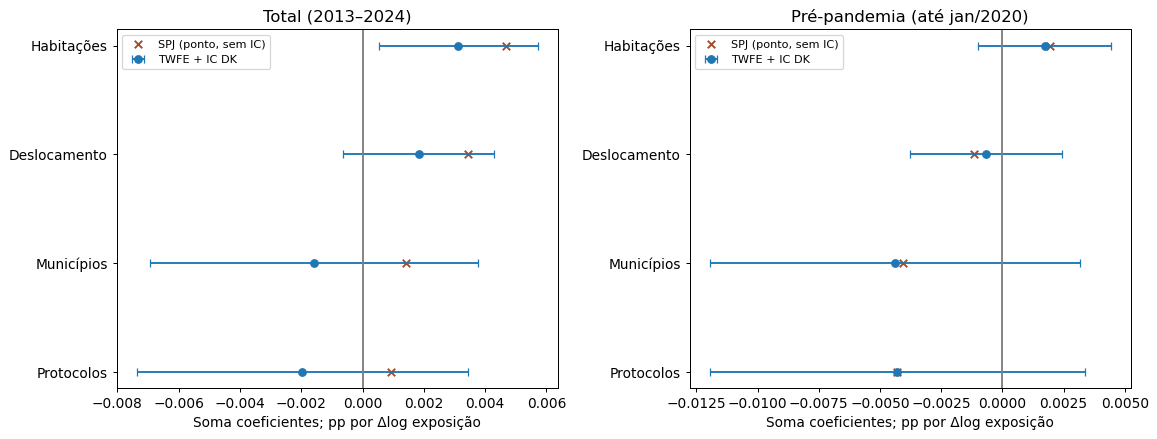

In [3]:
tabela(read('estacionariedade_uf'))
tabela(r[['Período','Exposição','n efetivo','Meses efetivos','p','p BH','Autocorrelação p DK','Proporção UF estacionária','Raiz própria','Soma coeficientes','Soma SPJ','Δ SPJ','Soma metade1','Soma metade2','LOO mínimo','LOO máximo','Diagnóstico favorável']])
figura_painel()

## 3. Coeficientes e influência
Coeficientes e IC em pp de ΔI por unidade de Δlog da exposição. A soma dos três lags não é efeito causal nem resposta acumulada. Retirar uma UF é sensibilidade; nenhuma UF é excluída permanentemente por apresentar resultado desfavorável. Nenhum estado é destacado apenas por significância.

In [4]:
tabela(read('coeficientes_painel'))
tabela(read('influencia_uf'))
checkpoint('12')

,Período,Unidade,Exposição,Família,Modelo,Transformação,Controles,p próprio,q exposição,Termo,Coeficiente,SE DK,IC baixo,IC alto,Coeficiente SPJ
0,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,I1,0.08640,0.05507,-0.02679,0.19960,-0.01659
1,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,I2,0.08873,0.02627,0.03473,0.14274,0.15753
2,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,I3,-0.11821,0.09020,-0.30362,0.06719,-0.25926
3,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,I12,0.11918,0.03898,0.03905,0.19931,0.03140
4,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,D1,0.00034,0.00101,-0.00173,0.00241,0.00123
5,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,D2,-0.00113,0.00122,-0.00365,0.00138,-0.00016
6,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,D3,-0.00117,0.00152,-0.00428,0.00195,-0.00015
7,Total (2013–2024),UF × mês,Clima | Municípios,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,I1,0.08639,0.05505,-0.02678,0.19955,-0.01653
8,Total (2013–2024),UF × mês,Clima | Municípios,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,I2,0.08868,0.02626,0.03471,0.14265,0.15763
9,Total (2013–2024),UF × mês,Clima | Municípios,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,I3,-0.11822,0.09017,-0.30356,0.06713,-0.25933


,Período,Unidade,Exposição,Família,Modelo,Transformação,Controles,p próprio,q exposição,UF removida,Soma sem UF
0,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,AC,-0.00251
1,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,AL,-0.00184
2,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,AM,-0.00174
3,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,AP,-0.00222
4,Total (2013–2024),UF × mês,Clima | Protocolos,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,BA,-0.00144
...,...,...,...,...,...,...,...,...,...,...,...
211,Pré-pandemia (até jan/2020),UF × mês,Clima | Habitações,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,RS,0.00157
212,Pré-pandemia (até jan/2020),UF × mês,Clima | Habitações,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,SC,0.00150
213,Pré-pandemia (até jan/2020),UF × mês,Clima | Habitações,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,SE,0.00181
214,Pré-pandemia (até jan/2020),UF × mês,Clima | Habitações,PAINEL,"ADL ΔI TWFE; I1,I2,I3,I12; D1,D2,D3",ΔI; Δlog exposição,FE UF + FE mês calendário,"1,2,3,12 fixos",3,SP,0.00182
